# Project 2 - Horse Colic

## Research question
What are the main indicators of colic severity in horses, and is it possible to track them with wearables?

Colic is a common but incredibly dangerous medical condition for horses. It presents suddenly, requires immediate treatment, and is the leading cause of death in horses. The Horse Colic dataset from UCI Machine Learning Repository contains data on many different biometrics, many of which could be tracked with wearables. I want to use a decision tree to explore which factors play the biggest role in the severity of the condition, meaning which ones lead to fatalities. If several key metrics are trackable with wearable devices, then it could lead to owners being notified of a potential problem and horses getting early treatment.

After learning more about real time monitoring and wearables in the guest lecture today, I brought up the possibility of extending it to equestrian athletes and veterinary science with my group. Animals struggle to communicate their discomfort, so real time data analysis could make a huge difference in animal healthcare. We discussed possible applications of real time monitoring, and decided the horses in the equestrian industry seemed like a good place to start due to the well established history and economic significance. A lot of biological data is collected on horses, so datasets are available to train a machine learning model. The equestrian industry has a clear economic incentive to maintain the health of these high value horses and invest in improvements to healthcare technology. Most importantly, developing a method of predicting colic could save countless horses' lives.

In [ ]:
# imports
import pandas as pd

### Loading the Datasets

The data is split up into three files, horse-colic.data, horse-colic.test, and horse-colic.names. The data is already separated into a train and test split, so that step is already complete and won't be needed later. The .data and .test files don't have the column headers, which are detailed in .names, so those will be added in manually.

In [15]:
df = pd.read_csv(
    "datasets/horse-colic.data",
    delim_whitespace=True,   # space separated
    header=None,             # no column names in file
    na_values="?"            # treat ? as NaN
)
df.head()

C:\Users\KayleePatersonBICTUS\AppData\Local\Temp\ipykernel_716\1923949867.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,NaN,2.0,...,45.0,8.4,NaN,NaN,2.0,2,11300,0,0,2
1,1.0,1,534817,39.2,88.0,20.0,NaN,NaN,4.0,1.0,...,50.0,85.0,2.0,2.0,3.0,2,2208,0,0,2
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,...,33.0,6.7,NaN,NaN,1.0,2,0,0,0,1
3,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,...,48.0,7.2,3.0,5.3,2.0,1,2208,0,0,1
4,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0,2.0,...,74.0,7.4,NaN,NaN,2.0,2,4300,0,0,2


In [16]:
columns = [
    "surgery", "age", "hospital_number", "rectal_temp", "pulse",
    "respiratory_rate", "temp_extremities", "peripheral_pulse",
    "mucous_membranes", "capillary_refill_time", "pain",
    "peristalsis", "abdominal_distension", "nasogastric_tube",
    "nasogastric_reflux", "nasogastric_reflux_ph", "rectal_exam_feces",
    "abdomen", "packed_cell_volume", "total_protein",
    "abdominocentesis_appearance", "abdom_protein", "outcome",
    "surgical_lesion", "type_of_lesion_1", "type_of_lesion_2",
    "type_of_lesion_3", "cp_data"
]

df.columns = columns

In [17]:
df.head()

,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,...,packed_cell_volume,total_protein,abdominocentesis_appearance,abdom_protein,outcome,surgical_lesion,type_of_lesion_1,type_of_lesion_2,type_of_lesion_3,cp_data
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,NaN,2.0,...,45.0,8.4,NaN,NaN,2.0,2,11300,0,0,2
1,1.0,1,534817,39.2,88.0,20.0,NaN,NaN,4.0,1.0,...,50.0,85.0,2.0,2.0,3.0,2,2208,0,0,2
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,...,33.0,6.7,NaN,NaN,1.0,2,0,0,0,1
3,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,...,48.0,7.2,3.0,5.3,2.0,1,2208,0,0,1
4,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0,2.0,...,74.0,7.4,NaN,NaN,2.0,2,4300,0,0,2


In [18]:
df_test = pd.read_csv(
    "datasets/horse-colic.test",
    delim_whitespace=True,
    header=None,
    na_values="?"
)

df_test.columns = columns

df.head()

C:\Users\KayleePatersonBICTUS\AppData\Local\Temp\ipykernel_716\735637688.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_test = pd.read_csv(


,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,...,packed_cell_volume,total_protein,abdominocentesis_appearance,abdom_protein,outcome,surgical_lesion,type_of_lesion_1,type_of_lesion_2,type_of_lesion_3,cp_data
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,NaN,2.0,...,45.0,8.4,NaN,NaN,2.0,2,11300,0,0,2
1,1.0,1,534817,39.2,88.0,20.0,NaN,NaN,4.0,1.0,...,50.0,85.0,2.0,2.0,3.0,2,2208,0,0,2
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,...,33.0,6.7,NaN,NaN,1.0,2,0,0,0,1
3,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,...,48.0,7.2,3.0,5.3,2.0,1,2208,0,0,1
4,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0,2.0,...,74.0,7.4,NaN,NaN,2.0,2,4300,0,0,2


In [19]:
df.isna().sum()

surgery                          1
age                              0
hospital_number                  0
rectal_temp                     60
pulse                           24
respiratory_rate                58
temp_extremities                56
peripheral_pulse                69
mucous_membranes                47
capillary_refill_time           32
pain                            55
peristalsis                     44
abdominal_distension            56
nasogastric_tube               104
nasogastric_reflux             106
nasogastric_reflux_ph          247
rectal_exam_feces              102
abdomen                        118
packed_cell_volume              29
total_protein                   33
abdominocentesis_appearance    165
abdom_protein                  198
outcome                          1
surgical_lesion                  0
type_of_lesion_1                 0
type_of_lesion_2                 0
type_of_lesion_3                 0
cp_data                          0
dtype: int64

In [20]:
df.dtypes

surgery                        float64
age                              int64
hospital_number                  int64
rectal_temp                    float64
pulse                          float64
respiratory_rate               float64
temp_extremities               float64
peripheral_pulse               float64
mucous_membranes               float64
capillary_refill_time          float64
pain                           float64
peristalsis                    float64
abdominal_distension           float64
nasogastric_tube               float64
nasogastric_reflux             float64
nasogastric_reflux_ph          float64
rectal_exam_feces              float64
abdomen                        float64
packed_cell_volume             float64
total_protein                  float64
abdominocentesis_appearance    float64
abdom_protein                  float64
outcome                        float64
surgical_lesion                  int64
type_of_lesion_1                 int64
type_of_lesion_2         

In [21]:
df_test.isna().sum()

surgery                         1
age                             0
hospital_number                 0
rectal_temp                     9
pulse                           2
respiratory_rate               13
temp_extremities                9
peripheral_pulse               14
mucous_membranes                1
capillary_refill_time           6
pain                            8
peristalsis                     8
abdominal_distension            9
nasogastric_tube               27
nasogastric_reflux             27
nasogastric_reflux_ph          52
rectal_exam_feces              26
abdomen                        25
packed_cell_volume              8
total_protein                  10
abdominocentesis_appearance    29
abdom_protein                  37
outcome                         1
surgical_lesion                 0
type_of_lesion_1                0
type_of_lesion_2                0
type_of_lesion_3                0
cp_data                         0
dtype: int64

In [22]:
df_test.dtypes

surgery                        float64
age                              int64
hospital_number                  int64
rectal_temp                    float64
pulse                          float64
respiratory_rate               float64
temp_extremities               float64
peripheral_pulse               float64
mucous_membranes               float64
capillary_refill_time          float64
pain                           float64
peristalsis                    float64
abdominal_distension           float64
nasogastric_tube               float64
nasogastric_reflux             float64
nasogastric_reflux_ph          float64
rectal_exam_feces              float64
abdomen                        float64
packed_cell_volume             float64
total_protein                  float64
abdominocentesis_appearance    float64
abdom_protein                  float64
outcome                        float64
surgical_lesion                  int64
type_of_lesion_1                 int64
type_of_lesion_2         

### Data Cleaning

There is a lot of missing data in the dataset. It also looks like the lesion column did not import properly, it is supposed to be split into three columns but is currently in one col. 

I am chosing to fillna with the median value, since it is resistant to outliers and dropping na would drop too much of the dataset.

Before continuing with the more manual data cleaning, I'm going to get rid of the columns that I don't need. The focus of this project is wearables, and not all of these biometrics can be gathered from wearables. Everything that requires a physical examination from a veterinarian is going to be dropped. This will be determined by reading through the data explanations in horse-colic.names.

In [26]:
wearable_cols = [
    "rectal_temp",          # body temperature
    "pulse",                # heart rate
    "respiratory_rate",     # can be estimated via sensors
    "temp_extremities",     # thermal sensors on limbs
    "peripheral_pulse",     # indirectly gathered from circulation sensors
    "peristalsis",          # gut sounds via acoustic sensors
    "abdominal_distension"  # potentially gathered via girth sensors/pressure
]

In [34]:
# Features and target
X_train = df[wearable_cols]
y_train = df["outcome"]

X_test = df_test[wearable_cols]
y_test = df_test["outcome"]

In [35]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [37]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=4,
)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4)

In [40]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=wearable_cols
).sort_values(ascending=False)

feature_importance

pulse                   0.424328
rectal_temp             0.286033
temp_extremities        0.153012
abdominal_distension    0.059943
peripheral_pulse        0.038667
peristalsis             0.038017
respiratory_rate        0.000000
dtype: float64

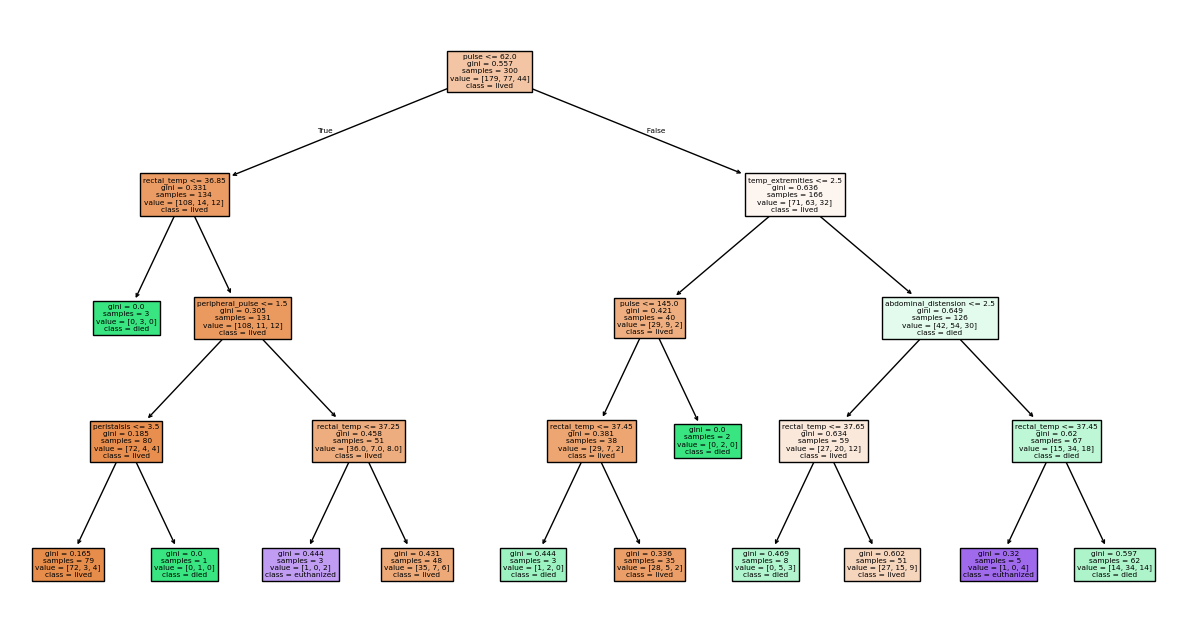

In [41]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
plot_tree(
    model,
    feature_names=wearable_cols,
    class_names=["lived", "died", "euthanized"],
    filled=True
)
plt.show()

In [42]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7058823529411765
              precision    recall  f1-score   support

         1.0       0.83      0.83      0.83        48
         2.0       0.37      0.58      0.45        12
         3.0       1.00      0.12      0.22         8

    accuracy                           0.71        68
   macro avg       0.73      0.51      0.50        68
weighted avg       0.77      0.71      0.69        68



The macro recall isnt great, 51%. Recall is the priority here, I don't want any horses to fall through the cracks. I'm going to try combining died and euthanized into one category for bad outcome, since the differentiation doesn't matter if I am simply trying to calculate severity.

In [43]:
y_test.value_counts()

outcome
1.0    48
2.0    12
3.0     8
Name: count, dtype: int64

In [44]:
y_train.value_counts()

outcome
1.0    179
2.0     77
3.0     44
Name: count, dtype: int64

In [45]:
y_train = y_train.replace({1: "lived", 2: "died", 3: "died"})
y_test = y_test.replace({1: "lived", 2: "died", 3: "died"})
print(y_train.value_counts())
print(y_test.value_counts())

outcome
lived    179
died     121
Name: count, dtype: int64
outcome
lived    48
died     20
Name: count, dtype: int64


In [46]:
# retrain model
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7941176470588235
              precision    recall  f1-score   support

        died       0.67      0.60      0.63        20
       lived       0.84      0.88      0.86        48

    accuracy                           0.79        68
   macro avg       0.75      0.74      0.74        68
weighted avg       0.79      0.79      0.79        68



This is already a major improvement in overall recall score. I'm going to try a few things to help improve it even further.

In [47]:
model = DecisionTreeClassifier(
    max_depth=4,
    class_weight={"lived": 1, "died": 3}  # increase weight on "died"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6176470588235294
              precision    recall  f1-score   support

        died       0.41      0.70      0.52        20
       lived       0.82      0.58      0.68        48

    accuracy                           0.62        68
   macro avg       0.62      0.64      0.60        68
weighted avg       0.70      0.62      0.63        68



The recall on Died went up, but the overall recall is lower. I'm going to try increasing model complexity.

In [48]:
model = DecisionTreeClassifier(
    max_depth=6,              # increase depth
    min_samples_leaf=5,       # avoid overfitting
    class_weight={"lived": 1, "died": 3}
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6617647058823529
              precision    recall  f1-score   support

        died       0.44      0.60      0.51        20
       lived       0.80      0.69      0.74        48

    accuracy                           0.66        68
   macro avg       0.62      0.64      0.63        68
weighted avg       0.70      0.66      0.67        68



The decision tree still isn't helping. Trying a different model entirely might help. The random forest model might help reduce overfitting and provide more generalized predictions for complicated patterns. It is more robust against unreliable data, which is very valuable for this dataset.

In [50]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    class_weight={"lived": 1, "died": 3},
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7941176470588235
              precision    recall  f1-score   support

        died       0.62      0.75      0.68        20
       lived       0.89      0.81      0.85        48

    accuracy                           0.79        68
   macro avg       0.76      0.78      0.76        68
weighted avg       0.81      0.79      0.80        68



The random forest is performing much better. The interpretability is lower, but I believe that is a fine trade in this use case. I'm going to try some hyperparameter tuning to make the model even more accurate.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,          # increase number of trees
    max_depth=8,               # more complexity
    min_samples_leaf=3,        # reduce overfitting
    class_weight={"lived": 1, "died": 4},  # increase bias toward recall
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight={'died': 4, 'lived': 1}, max_depth=8,
                       min_samples_leaf=3, n_estimators=300)

In [54]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7647058823529411
              precision    recall  f1-score   support

        died       0.57      0.80      0.67        20
       lived       0.90      0.75      0.82        48

    accuracy                           0.76        68
   macro avg       0.74      0.78      0.74        68
weighted avg       0.80      0.76      0.77        68



In [55]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=wearable_cols
).sort_values(ascending=False)

print(feature_importance)

pulse                   0.283607
respiratory_rate        0.147338
rectal_temp             0.143435
peripheral_pulse        0.132268
temp_extremities        0.115223
abdominal_distension    0.098408
peristalsis             0.079721
dtype: float64


I adjusted the class weights to improve recall again, which was very helpful in improving the random forest. The overall complexity was also increased with more trees and more depth. These changes improved the model's ability to identify high risk outcomes, which can make a massive difference in early intervention and treatment. 